# 🔍 Customer Data Analysis for Business Insights

# Project Overview
A mid-sized Indian retail company wants to analyze its customer base to improve
targeted marketing, retain valuable customers, and detect patterns in customer
behavior. You have been hired as a data analyst to clean, process, and analyze the
customer transaction data to generate actionable insights.
Your goal is to:
- Assess customer demographics and transaction behavior
- Clean and prepare the data for analysis
- Conduct RFM (Recency, Frequency, Monetary) analysis
- Visualize key patterns using charts
Key Goals:
- Detect incomplete, inconsistent, or duplicate customer records and improve data
quality, if applicable
- Segment customers based on demographics and purchase behavior
- Identify high-value customers using Recency-Frequency-Monetary (RFM) analysis
- Visualize customer distribution across geographies, age groups, or income
brackets
- Generate actionable insights for marketing departmen

# Python Execution 
## Step 1:
- Load the Data
-   Load both CSVs into Pandas DataFrames
-  Check shape, structure, preview

## Loding our libraries

In [47]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Loading both datasets:-

In [48]:
customers = pd.read_csv("Customer_Master_Data.csv")
transactions = pd.read_csv("Customer_Transactions.csv")

## Since we have two datasets, one for Customers and one for Transactions, we are going to focus on both datasets together:-

In [49]:
print(customers.head())
print(transactions.head())

  CustomerID            Name                    Email  Gender  Age     City  \
0  CUST10000  Onkar Bhargava          pkeer@yahoo.com    Male   54    Delhi   
1  CUST10001     Divit Kohli        mkalita@sarin.com  Female   48  Kolkata   
2  CUST10002      Kiara Behl     apteanay@hotmail.com    Male   75  Kolkata   
3  CUST10003  Vaibhav Sankar  bseshadri@choudhry.info    Male   62     Pune   
4  CUST10004    Shray D’Alia   bdhillon@toor-mall.com    Male   55    Delhi   

  MaritalStatus  NumChildren    JoinDate  
0      Divorced            0  2021-02-22  
1       Married            0  2023-12-06  
2       Widowed            2  2023-08-23  
3      Divorced            2  2022-11-17  
4      Divorced            0  2022-12-04  
  CustomerID TransactionDate  TransactionAmount
0  CUST10771         7/31/23            2383.07
1  CUST10100         3/10/24             497.54
2  CUST10031         2/17/25             536.78
3  CUST10987         7/17/23             314.89
4  CUST10831        12/15/2

## Step 2: Clean the Data
- Convert JoinDate and TransactionDate columns to datetime
- Ensure no nulls or bad types
- Validate uniqueness of CustomerID in master dataset
- Ensure all transaction CustomerIDs exist in master data

In [50]:
customers.isnull().sum()


CustomerID       0
Name             0
Email            0
Gender           0
Age              0
City             0
MaritalStatus    0
NumChildren      0
JoinDate         0
dtype: int64

In [51]:
transactions.isnull().sum()



CustomerID           0
TransactionDate      0
TransactionAmount    0
dtype: int64

In [52]:

customers.info()
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1000 non-null   object
 1   Name           1000 non-null   object
 2   Email          1000 non-null   object
 3   Gender         1000 non-null   object
 4   Age            1000 non-null   int64 
 5   City           1000 non-null   object
 6   MaritalStatus  1000 non-null   object
 7   NumChildren    1000 non-null   int64 
 8   JoinDate       1000 non-null   object
dtypes: int64(2), object(7)
memory usage: 70.4+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23050 entries, 0 to 23049
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         23050 non-null  object 
 1   TransactionDate    23050 non-null  object 
 2   TransactionAmount  23050 non-null  float64
dtypes: float64(1), obj

## Observation:-  Our data has no null.

In [54]:
customers['JoinDate'] = pd.to_datetime(customers['JoinDate'],errors='coerce')
transactions['TransactionDate'] = pd.to_datetime(transactions['TransactionDate'],errors='coerce')

In [55]:
print(customers.head())
print(transactions.head())

  CustomerID            Name                    Email  Gender  Age     City  \
0  CUST10000  Onkar Bhargava          pkeer@yahoo.com    Male   54    Delhi   
1  CUST10001     Divit Kohli        mkalita@sarin.com  Female   48  Kolkata   
2  CUST10002      Kiara Behl     apteanay@hotmail.com    Male   75  Kolkata   
3  CUST10003  Vaibhav Sankar  bseshadri@choudhry.info    Male   62     Pune   
4  CUST10004    Shray D’Alia   bdhillon@toor-mall.com    Male   55    Delhi   

  MaritalStatus  NumChildren   JoinDate  
0      Divorced            0 2021-02-22  
1       Married            0 2023-12-06  
2       Widowed            2 2023-08-23  
3      Divorced            2 2022-11-17  
4      Divorced            0 2022-12-04  
  CustomerID TransactionDate  TransactionAmount
0  CUST10771      2023-07-31            2383.07
1  CUST10100      2024-03-10             497.54
2  CUST10031      2025-02-17             536.78
3  CUST10987      2023-07-17             314.89
4  CUST10831      2024-12-15     

## Observation:- TransactionDate and JoinDate are converted in  date datatype here.

In [56]:
print(customers['CustomerID'].nunique())
print(transactions['CustomerID'].nunique())


1000
1000


## obsevation"- We have 1000 raws are unique.

In [57]:
print(len(customers))
print(len(transactions))

1000
23050


In [58]:
customers.describe(include='object')

,CustomerID,Name,Email,Gender,City,MaritalStatus
count,1000,1000,1000,1000,1000,1000
unique,1000,993,1000,3,10,4
top,CUST10000,Anahita Buch,pkeer@yahoo.com,Female,Lucknow,Widowed
freq,1,2,1,340,110,280


In [59]:
transactions.describe(include='object')

,CustomerID
count,23050
unique,1000
top,CUST10851
freq,38


In [60]:
transactions.describe()

,TransactionDate,TransactionAmount
count,23050,23050.000000
mean,2024-01-22 02:29:03.618221312,1000.138814
min,2020-08-22 00:00:00,3.870000
25%,2023-05-07 00:00:00,482.107500
50%,2024-04-21 00:00:00,844.755000
75%,2024-12-12 00:00:00,1346.795000
max,2025-07-29 00:00:00,6890.190000
std,NaN,703.358978


## Data seems to have outliers

## Step 3: Merge if Needed
- Join Customer_Master_Data with Customer_Transactions on CustomerID (if
demographic data is required)

In [61]:
df = pd.merge(transactions, customers, on='CustomerID', how='inner')

In [62]:
display(df)

,CustomerID,TransactionDate,TransactionAmount,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10771,2023-07-31,2383.07,Lakshay Dhillon,dharmajantara@gmail.com,Female,27,Ahmedabad,Widowed,3,2023-05-31
1,CUST10100,2024-03-10,497.54,Aniruddh Borah,jivikabhavsar@gmail.com,Female,53,Lucknow,Divorced,4,2022-01-08
2,CUST10031,2025-02-17,536.78,Ritvik Ahuja,jhaverifarhan@chandra.org,Male,40,Ahmedabad,Single,0,2023-12-03
3,CUST10987,2023-07-17,314.89,Jayan Wagle,ojas82@gmail.com,Not Disclosed,75,Bangalore,Widowed,4,2022-03-18
4,CUST10831,2024-12-15,2543.19,Ishita Agarwal,vbalay@yahoo.com,Not Disclosed,27,Jaipur,Divorced,4,2021-06-30
...,...,...,...,...,...,...,...,...,...,...,...
23045,CUST10710,2024-03-11,931.09,Divit Toor,saksham79@ram.biz,Not Disclosed,73,Mumbai,Widowed,1,2024-02-18
23046,CUST10209,2024-06-19,2659.35,Jivin Cheema,darivana@hotmail.com,Male,56,Pune,Married,1,2024-05-09
23047,CUST10570,2024-06-27,266.97,Advika Dyal,granganathan@sathe-dhar.org,Not Disclosed,26,Pune,Single,1,2021-03-29
23048,CUST10075,2023-12-26,1671.73,Amira Lall,vanyabiswas@kannan.biz,Female,29,Jaipur,Married,1,2023-02-25


## Observation:- Showing 23050 raws and 11 columns are merged together.

In [63]:
df = df.drop_duplicates()


## Step 4: Perform RFM Calculation
- Use groupby on CustomerID for:
- max(TransactionDate) → Recency
- count(TransactionDate) → Frequency
- sum(TransactionAmount) → Monetary
- Use a reference date to compute Recency in number of days
- Store result in a new DataFrame called df_rfm

## 🧠 RFM Analysis

In [64]:
snapshot_date = df['TransactionDate'].max() + pd.Timedelta(days=1)
snapshot_date 

Timestamp('2025-07-30 00:00:00')

## Action:- Creating a new df_rfm with three new columns:-

In [65]:
df_rfm = df.groupby('CustomerID').agg({
    'TransactionDate': lambda x: (snapshot_date - x.max()).days,
    'CustomerID': 'count',
    'TransactionAmount': 'sum'
})
df_rfm.columns = ['Recency', 'Frequency', 'Monetary']
display(df_rfm)


,Recency,Frequency,Monetary
CustomerID,,,
CUST10000,13,23,21265.49
CUST10001,35,30,28654.31
CUST10002,18,24,23884.03
CUST10003,81,25,24206.03
CUST10004,8,19,25565.30
...,...,...,...
CUST10995,402,21,24325.19
CUST10996,15,21,21809.11
CUST10997,32,20,21120.48


In [66]:
df_rfm = df_rfm.reset_index()
display(df_rfm)

,CustomerID,Recency,Frequency,Monetary
0,CUST10000,13,23,21265.49
1,CUST10001,35,30,28654.31
2,CUST10002,18,24,23884.03
3,CUST10003,81,25,24206.03
4,CUST10004,8,19,25565.30
...,...,...,...,...
995,CUST10995,402,21,24325.19
996,CUST10996,15,21,21809.11
997,CUST10997,32,20,21120.48
998,CUST10998,126,25,29494.56


## Step 5: Score RFM
- Use quantile-based scoring using pd.qcut() or rank() and cut()
- Create three new columns: R_Score, F_Score, M_Score

## 🔢 RFM Scoring

### Action:-In our 'df_rfm' dataframe,we are creating three (R_Score,F_Score,M_Score) new columns and assigning scoring.

In [67]:
df_rfm['R_Score'] = pd.qcut(df_rfm['Recency'], 5, labels=[5,4,3,2,1])
df_rfm['F_Score'] = pd.qcut(df_rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
df_rfm['M_Score'] = pd.qcut(df_rfm['Monetary'], 5, labels=[1,2,3,4,5])
display(df_rfm)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,CUST10000,13,23,21265.49,4,3,2
1,CUST10001,35,30,28654.31,3,5,5
2,CUST10002,18,24,23884.03,4,3,3
3,CUST10003,81,25,24206.03,1,4,3
4,CUST10004,8,19,25565.30,5,1,4
...,...,...,...,...,...,...,...
995,CUST10995,402,21,24325.19,1,2,3
996,CUST10996,15,21,21809.11,4,2,3
997,CUST10997,32,20,21120.48,3,2,2
998,CUST10998,126,25,29494.56,1,4,5


## Step 6: Create Combined RFM Segment
- Concatenate the R, F, M scores into a string like "555", "432", etc.

### Action:- By appending as text we are generating a new 'RFM_Segment' column for finding RFM segment.

In [68]:
df_rfm['RFM_Segment'] = (
    df_rfm['R_Score'].astype(str) +
    df_rfm['F_Score'].astype(str) +
    df_rfm['M_Score'].astype(str)
)
display(df_rfm)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment
0,CUST10000,13,23,21265.49,4,3,2,432
1,CUST10001,35,30,28654.31,3,5,5,355
2,CUST10002,18,24,23884.03,4,3,3,433
3,CUST10003,81,25,24206.03,1,4,3,143
4,CUST10004,8,19,25565.30,5,1,4,514
...,...,...,...,...,...,...,...,...
995,CUST10995,402,21,24325.19,1,2,3,123
996,CUST10996,15,21,21809.11,4,2,3,423
997,CUST10997,32,20,21120.48,3,2,2,322
998,CUST10998,126,25,29494.56,1,4,5,145


## Step 7: Assign Segment Labels
- Use business rules to define segment labels for selected score combinations
- Example:
- RFM 555 → Champion
- RFM 111 → Lost
(Refer RFM explanation above)

### Action:-By defining a 'segment' row , we are assigning Segment Labels.

In [31]:
def segment(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif f >= 4:
        return "Loyal Customers"
    elif r >= 4 and f >= 2:
        return "Potential Loyalists"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r == 1:
        return "Lost"
    elif m >= 4:
        return "Big Spenders"
    else:
        return "Others"
display(df_rfm)


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,Segment
0,CUST10000,13,23,21265.49,4,3,2,432,Potential Loyalists
1,CUST10001,35,30,28654.31,3,5,5,355,Loyal Customers
2,CUST10002,18,24,23884.03,4,3,3,433,Potential Loyalists
3,CUST10003,81,25,24206.03,1,4,3,143,Loyal Customers
4,CUST10004,8,19,25565.30,5,1,4,514,Big Spenders
...,...,...,...,...,...,...,...,...,...
995,CUST10995,402,21,24325.19,1,2,3,123,Lost
996,CUST10996,15,21,21809.11,4,2,3,423,Potential Loyalists
997,CUST10997,32,20,21120.48,3,2,2,322,Others
998,CUST10998,126,25,29494.56,1,4,5,145,Loyal Customers


## Step 8: Visualize
- Count of customers in each segment
- Revenue contribution per segment
- Recency vs Monetary scatter plot colored by segment
- Pareto Analysis: Show how top 20% customers contribute to 80% revenue

C:\Users\sushm\AppData\Local\Temp\ipykernel_14312\2687409696.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Segment', data=df_rfm, palette='viridis', order=df_rfm['Segment'].value_counts().index)


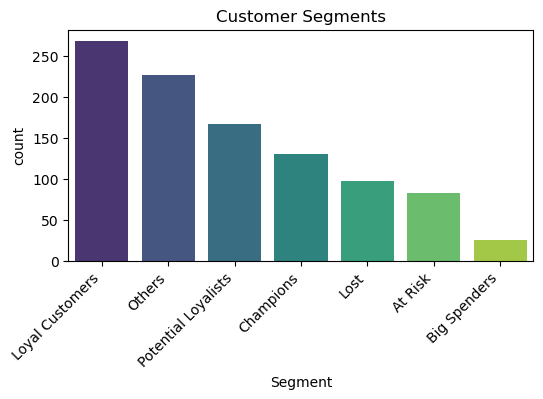

In [69]:
df_rfm['Segment'] = df_rfm.apply(segment, axis=1)
plt.figure(figsize=(6,3))
sns.countplot(x='Segment', data=df_rfm, palette='viridis', order=df_rfm['Segment'].value_counts().index)
# display(df_rfm)
plt.xticks(rotation=45, ha='right' )
plt.title("Customer Segments")
plt.show()

### Obsevation:-
- The chart shows that Loyal Customers have the highest customers count, followed by Others and Potential Loyalists.
- The customer count decreases gradually across the segments
- Champions have a moderate number of customers.
- Lost and Risk segments contain fewer customers.
- Big Spenders have the lowest customer count.
- Most customers are concentrated in the Loyal Customers segment.

C:\Users\sushm\AppData\Local\Temp\ipykernel_14312\1980241135.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Segment', y='Monetary', data=data, palette='viridis')


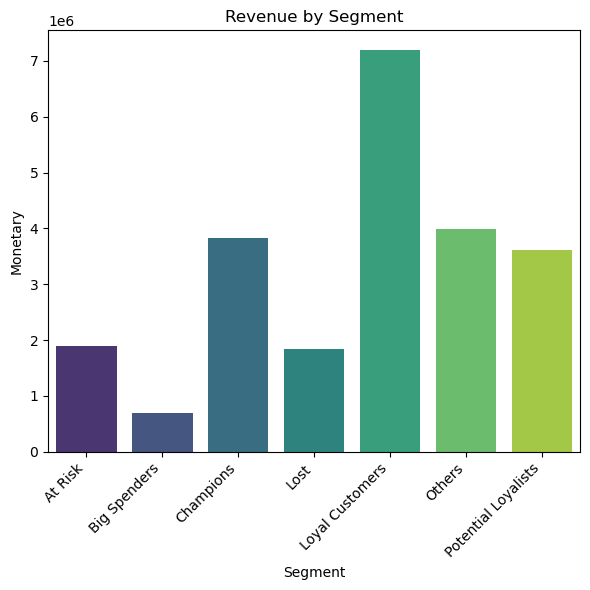

In [70]:
data = df_rfm.groupby('Segment')['Monetary'].sum().reset_index()

plt.figure(figsize=(6,6))

sns.barplot(x='Segment', y='Monetary', data=data, palette='viridis')

plt.xticks(rotation=45, ha='right')
plt.title("Revenue by Segment")

plt.tight_layout()
plt.show()

### Observatios:-

### 📊 Refined Insights from Revenue by Segment

1. **Loyal Customers** are the primary revenue drivers, contributing the highest share among all segments.

2. **Champions** and **Others** also make substantial contributions, indicating strong engagement beyond just loyal users.

3. **Potential Loyalists** generate significant revenue despite a smaller customer base, showing high future value potential.

4. **At Risk** and **Lost Customers** still contribute moderate revenue, suggesting opportunities for re-engagement strategies.

5. **Big Spenders** surprisingly contribute the least, which may indicate low frequency despite high transaction value.

6. Overall, revenue is heavily concentrated in **Loyal Customers, Champions, and Others**, highlighting the importance of retention.

7. Customer loyalty has a clear and strong impact on revenue, emphasizing the need for loyalty-focused marketing strategies.


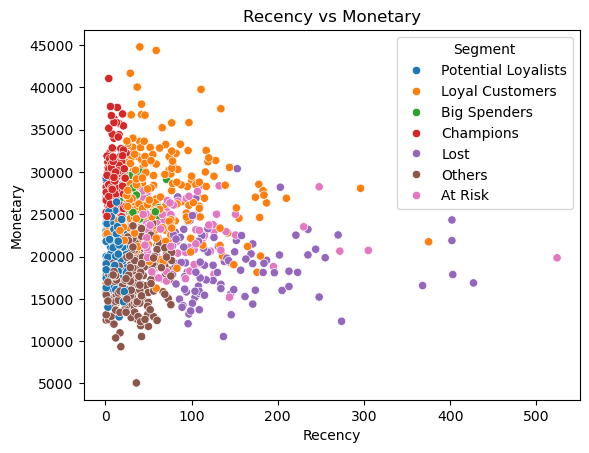

In [71]:
sns.scatterplot(x='Recency', y='Monetary', hue='Segment', data=df_rfm)
plt.title("Recency vs Monetary")
plt.show()

### Obsevations:-

### 📊 Key Insights: Recency vs Monetary Analysis

1. Customers with **low recency** are more active, as they have made purchases recently.

2. A large concentration of customers falls within the **0–100 recency range**, indicating a strong base of recent buyers.

3. **Champions** and **Loyal Customers** exhibit **higher monetary values**, confirming them as high-value segments.

4. **Big Spenders** are relatively few but contribute significantly on a per-customer basis.

5. **At Risk** and **Lost Customers** show **high recency values**, highlighting reduced engagement or churn.

6. A small group of customers with **very high recency (300–500+)** are likely inactive and may require reactivation strategies—or exclusion from active targeting.

7. Most customers spend in the range of **₹15,000–₹35,000**, forming the core revenue band.

8. A limited number of customers spend above **₹40,000**, representing premium or high-value buyers.

9. There is a **slight negative relationship** between recency and monetary value—customers who haven’t purchased recently tend to spend less overall.



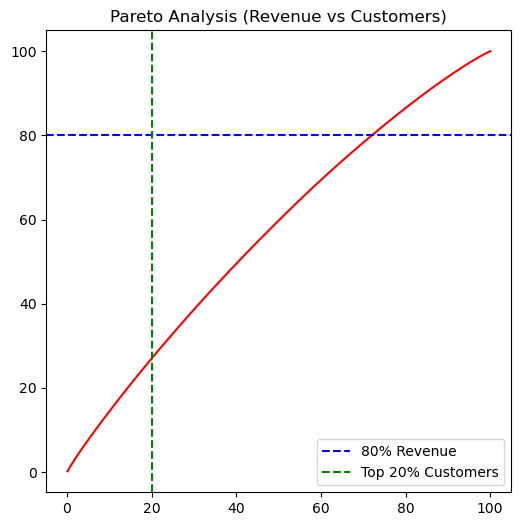

In [72]:
# 4. Pareto Analysis (80/20 Rule)

df_pareto = df_rfm[['CustomerID', 'Monetary']].sort_values(by='Monetary', ascending=False)

df_pareto['Cum_Percent'] = 100 * df_pareto['Monetary'].cumsum() / df_pareto['Monetary'].sum()

df_pareto['Cust_Percent'] = 100 * (np.arange(len(df_pareto)) + 1) / len(df_pareto)

plt.figure(figsize=(6,6))

plt.plot(df_pareto['Cust_Percent'], df_pareto['Cum_Percent'], color='red')

plt.axhline(y=80, color='blue', linestyle='--', label='80% Revenue')

plt.axvline(x=20, color='green', linestyle='--', label='Top 20% Customers')

plt.title('Pareto Analysis (Revenue vs Customers)')

plt.legend()

plt.savefig('pareto_analysis.png')

plt.show()

### Obsevations:-

### 📊 Key Insights: Pareto Analysis (Revenue vs Customers)

1. The chart demonstrates the **Pareto Principle (80/20 Rule)**, where a small proportion of customers drives a large share of revenue.

2. Approximately **top 20% of customers contribute around 80% of total revenue**, confirming a highly skewed revenue distribution.

3. The **cumulative revenue curve (red line)** rises steeply at the beginning, indicating that top customers generate disproportionately high sales.

4. The **80% revenue threshold (blue dashed line)** intersects early on the customer axis, reinforcing that fewer customers generate most revenue.

5. The **top 20% customer marker (green dashed line)** highlights the high-value segment critical to business performance.

6. Beyond this top segment, the remaining **80% of customers contribute relatively less revenue individually**, forming the long tail.

7. This distribution shows strong **customer inequality in revenue contribution**, common in retail and e-commerce bussinesses.


### Final action :- Creating our datesets as "RFM_Output.csv" and "Customers_data.csv"

In [73]:
final_data = pd.merge(df_rfm, customers, on='CustomerID')

In [74]:
df_rfm.to_csv("RFM_Output.csv", index=False)

In [75]:
final_data.to_csv("Customers_data.csv", index=False)

# Insights & Business Recommendations

## 📊 Key Insights from Customer Data Analysis

### 🔹 1. Customer Activity (Recency)

* Majority of customers have made **recent purchases**, indicating an **active customer base**.
* A small group of customers shows **high recency values**, meaning they haven’t purchased for a long time.
* These inactive customers represent an opportunity for **re-engagement campaigns**.

---

### 🔹 2. Purchase Behavior (Frequency)

* Most customers purchase **moderately (around average frequency)**.
* A smaller segment of customers shows **high frequency**, indicating **loyal and repeat buyers**.
* These loyal customers are valuable and should be targeted with **loyalty programs and rewards**.

---

### 🔹 3. Spending Pattern (Monetary)

* Customer spending is **normally distributed**, with most customers contributing a **moderate amount of revenue**.
* A few customers contribute **very high revenue**, representing **premium/high-value customers**.
* These customers should be prioritized for **exclusive offers and retention strategies**.

---

### 🔹 4. Customer Segmentation Insights

* Segments like **Champions and Loyal Customers** contribute significantly to business revenue.
* **Potential Loyalists** show promise and can be converted into loyal customers with proper engagement.
* **At Risk and Lost customers** require targeted campaigns to win them back.

---

### 🔹 5. Pareto Analysis (80/20 Rule)

* A small percentage of customers (around **20–30%**) contributes to nearly **80% of total revenue**.
* This indicates that revenue is **highly concentrated among top customers**.
* Focusing on these high-value customers can significantly improve business performance.

---

### 🔹 6. Business Recommendations

* Focus marketing efforts on **high-value and loyal customers**.
* Create **personalized offers** for potential loyalists.
* Launch **re-engagement campaigns** for inactive customers.
* Optimize marketing budget by targeting customers who generate the **most revenue**.

---

## 🧠 Conclusion

* The business has a **strong active customer base** with clear high-value segments.
* Customer segmentation using RFM helps identify **loyal, at-risk, and high-spending customers**.
* Strategic targeting based on these insights can improve **customer retention, revenue, and overall business growth**.
